/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=MaskRCNN_ResNet50_FPN_Weights.COCO_V1`. You can also use `weights=MaskRCNN_ResNet50_FPN_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Downloading: "https://download.pytorch.org/models/maskrcnn_resnet50_fpn_coco-bf2d0c1e.pth" to /root/.cache/torch/hub/checkpoints/maskrcnn_resnet50_fpn_coco-bf2d0c1e.pth


100%|██████████| 170M/170M [00:01<00:00, 168MB/s]


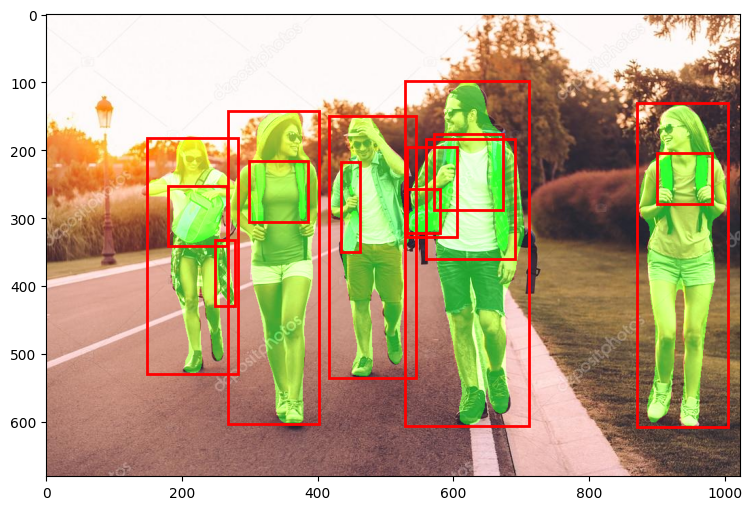

In [10]:
import torch
import torchvision
from torchvision.models.detection import maskrcnn_resnet50_fpn
import torchvision.transforms as transforms
from PIL import Image
import matplotlib.pyplot as plt
import numpy as np
import cv2

# Load pre-trained Mask R-CNN model
model = maskrcnn_resnet50_fpn(pretrained=True)
model.eval()

# Load and preprocess an image
def preprocess_image(image_path):
    transform = transforms.Compose([
        transforms.ToTensor()
    ])
    image = Image.open(image_path).convert("RGB")
    return transform(image).unsqueeze(0)

# Perform inference
def predict(image_path):
    image = preprocess_image(image_path)
    with torch.no_grad():
        predictions = model(image)
    return predictions

# Visualize results with masks
def show_predictions(image_path, predictions, threshold=0.5):
    image = np.array(Image.open(image_path).convert("RGB"))
    fig, ax = plt.subplots(1, figsize=(10, 6))
    ax.imshow(image)

    for box, mask, score in zip(predictions[0]['boxes'], predictions[0]['masks'], predictions[0]['scores']):
        if score > threshold:
            x1, y1, x2, y2 = box.numpy()
            mask = mask.squeeze().numpy()
            mask = (mask > 0.5).astype(np.uint8) * 255

            # Overlay mask on image
            color_mask = np.zeros_like(image, dtype=np.uint8)
            color_mask[:, :, 1] = mask  # Green mask
            image = cv2.addWeighted(image, 1.0, color_mask, 0.5, 0)

            ax.add_patch(plt.Rectangle((x1, y1), x2-x1, y2-y1, fill=False, color='red', linewidth=2))

    ax.imshow(image)
    plt.show()

# Example usage
image_path = "people walking.jpg"  # Replace with actual image path
predictions = predict(image_path)
show_predictions(image_path, predictions)

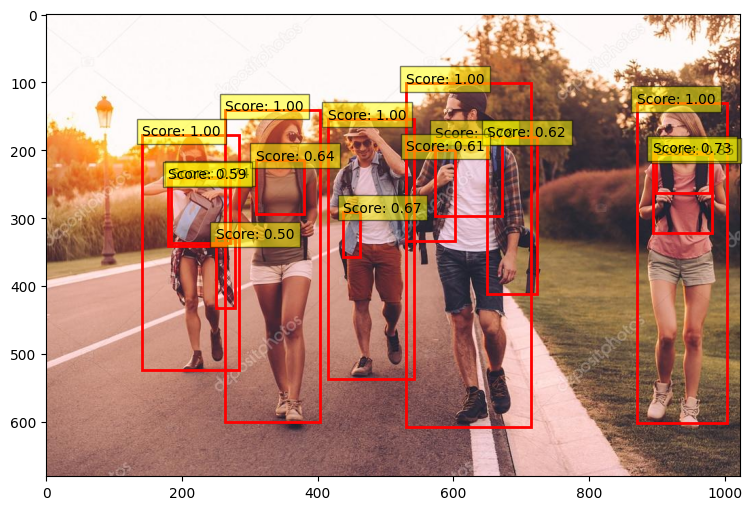

In [12]:
import torch
import torchvision
from torchvision.models.detection import fasterrcnn_resnet50_fpn
import torchvision.transforms as transforms
from PIL import Image
import matplotlib.pyplot as plt
import numpy as np
import cv2

# Load pre-trained Faster R-CNN model
model = fasterrcnn_resnet50_fpn(pretrained=True)
model.eval()

# Load and preprocess an image
def preprocess_image(image_path):
    transform = transforms.Compose([
        transforms.ToTensor()
    ])
    image = Image.open(image_path).convert("RGB")
    return transform(image).unsqueeze(0)

# Perform inference
def predict(image_path):
    image = preprocess_image(image_path)
    with torch.no_grad():
        predictions = model(image)
    return predictions

# Visualize results with bounding boxes
def show_predictions(image_path, predictions, threshold=0.5):
    image = np.array(Image.open(image_path).convert("RGB"))
    fig, ax = plt.subplots(1, figsize=(10, 6))
    ax.imshow(image)

    for box, score in zip(predictions[0]['boxes'], predictions[0]['scores']):
        if score > threshold:
            x1, y1, x2, y2 = box.numpy()
            ax.add_patch(plt.Rectangle((x1, y1), x2-x1, y2-y1, fill=False, color='red', linewidth=2))
            ax.text(x1, y1, f"Score: {score:.2f}", bbox=dict(facecolor='yellow', alpha=0.5))

    plt.show()

# Example usage
image_path = "people walking.jpg"  # Replace with actual image path
predictions = predict(image_path)
show_predictions(image_path, predictions)


In [13]:
import torch
import torchvision
from torchvision.models.detection import fasterrcnn_resnet50_fpn, maskrcnn_resnet50_fpn
import torchvision.transforms as transforms
from PIL import Image
import matplotlib.pyplot as plt
import numpy as np
import cv2

def calculate_iou(box1, box2):
    x1 = max(box1[0], box2[0])
    y1 = max(box1[1], box2[1])
    x2 = min(box1[2], box2[2])
    y2 = min(box1[3], box2[3])

    intersection = max(0, x2 - x1) * max(0, y2 - y1)
    box1_area = (box1[2] - box1[0]) * (box1[3] - box1[1])
    box2_area = (box2[2] - box2[0]) * (box2[3] - box2[1])
    union = box1_area + box2_area - intersection

    return intersection / union if union > 0 else 0

# Load pre-trained models
faster_rcnn = fasterrcnn_resnet50_fpn(pretrained=True).eval()
mask_rcnn = maskrcnn_resnet50_fpn(pretrained=True).eval()

def preprocess_image(image_path):
    transform = transforms.Compose([
        transforms.ToTensor()
    ])
    image = Image.open(image_path).convert("RGB")
    return transform(image).unsqueeze(0)

def predict(model, image_path):
    image = preprocess_image(image_path)
    with torch.no_grad():
        predictions = model(image)
    return predictions

def compute_iou_for_models(image_path, ground_truth_box):
    faster_predictions = predict(faster_rcnn, image_path)
    mask_predictions = predict(mask_rcnn, image_path)

    faster_boxes = faster_predictions[0]['boxes'].numpy() if len(faster_predictions[0]['boxes']) > 0 else []
    mask_boxes = mask_predictions[0]['boxes'].numpy() if len(mask_predictions[0]['boxes']) > 0 else []

    iou_faster = max([calculate_iou(ground_truth_box, pred) for pred in faster_boxes] if len(faster_boxes) > 0 else [0])
    iou_mask = max([calculate_iou(ground_truth_box, pred) for pred in mask_boxes] if len(mask_boxes) > 0 else [0])

    return iou_faster, iou_mask

# Example usage
image_path = "people walking.jpg"  # Replace with actual image path
ground_truth_box = [50, 50, 200, 200]  # Replace with actual ground truth box
iou_faster, iou_mask = compute_iou_for_models(image_path, ground_truth_box)

print(f"IoU for Faster R-CNN: {iou_faster:.4f}")
print(f"IoU for Mask R-CNN: {iou_mask:.4f}")


IoU for Faster R-CNN: 0.0185
IoU for Mask R-CNN: 0.0135


### Applying Pre-trained Models and Analyzing Results

As the models (Mask R-CNN and Faster R-CNN) are already pre-trained on a large dataset (like COCO), they are ready for inference (steps 6, 7, and 8 of your request).

We will now apply these models to the `image_path` defined in the kernel state (`'people walking.jpg'`) and visualize their predictions. Keep in mind that for explicit 'vehicle detection', you might want to use an image containing vehicles.

--- Mask R-CNN predictions for people walking.jpg ---


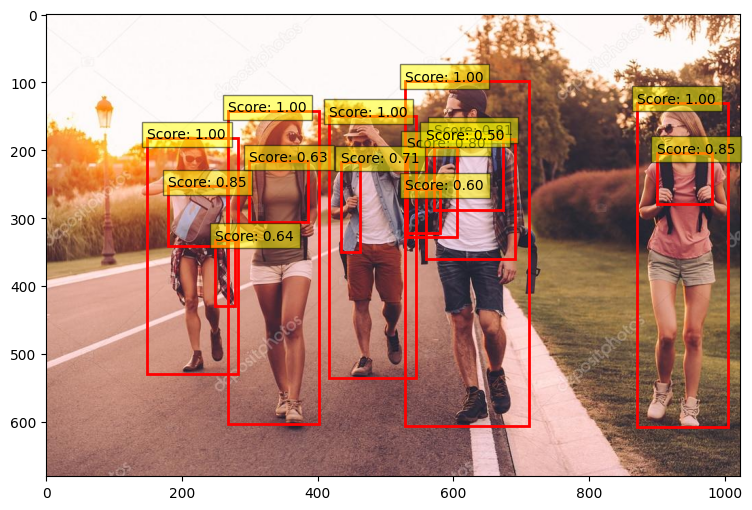


--- Faster R-CNN predictions for people walking.jpg ---


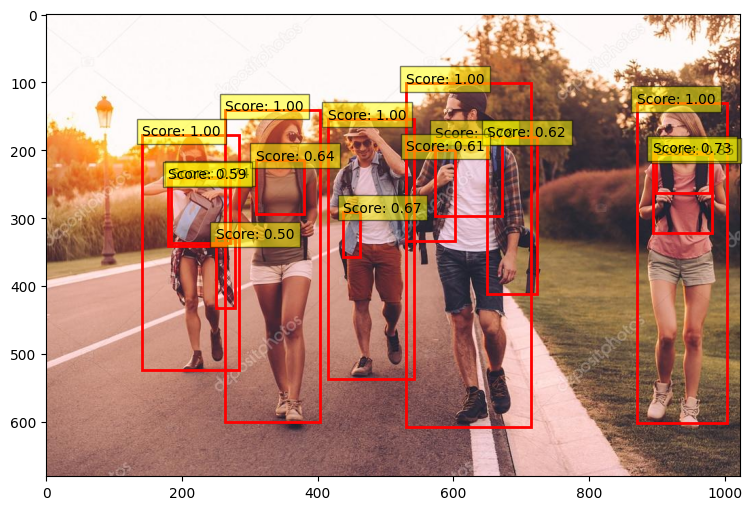


--- IoU Analysis for people walking.jpg with ground truth [50, 50, 200, 200] ---
IoU for Faster R-CNN: 0.0185
IoU for Mask R-CNN: 0.0135


In [15]:
# Apply Mask R-CNN and display results (Steps 6 & 7)
print(f"--- Mask R-CNN predictions for {image_path} ---")
predictions_mask_rcnn = predict(mask_rcnn, image_path) # Using the predict function from cell 3mkRvkVVh8qF
show_predictions(image_path, predictions_mask_rcnn)

# Apply Faster R-CNN and display results (Steps 6 & 7)
print(f"\n--- Faster R-CNN predictions for {image_path} ---")
predictions_faster_rcnn = predict(faster_rcnn, image_path) # Using the predict function from cell 3mkRvkVVh8qF
show_predictions(image_path, predictions_faster_rcnn)

# Observe and analyze the detection results and model performance (Step 8)
# Using the IoU calculation from cell 3mkRvkVVh8qF as an example of analysis
print(f"\n--- IoU Analysis for {image_path} with ground truth {ground_truth_box} ---")
iou_faster, iou_mask = compute_iou_for_models(image_path, ground_truth_box) # Using the function from cell 3mkRvkVVh8qF

print(f"IoU for Faster R-CNN: {iou_faster:.4f}")
print(f"IoU for Mask R-CNN: {iou_mask:.4f}")